creating an Agri-credit scoring and risk prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, f1_score
)
import category_encoders as ce
import warnings
warnings.filterwarnings('ignore')
 

now setting a general style for visualization of data later

In [2]:
sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize']= (12,6)
print("\n"+ "="*80)
print("FARMER CREDIT RISK MODEL - REAL DATA ANALYSIS")
print("="*80)
 


FARMER CREDIT RISK MODEL - REAL DATA ANALYSIS


now loading data

In [3]:
df_credit = pd.read_csv("agri_credit_data.csv")

In [4]:
print("\n📊 DATA SUMMARY:")
print(f"  Regions: {df_credit['region'].nunique()} unique - {dict(df_credit['region'].value_counts())}")
print(f"  Crops: {df_credit['primary_crop'].nunique()} unique - {dict(df_credit['primary_crop'].value_counts())}")
print(f"  Coop membership: {df_credit['coop_member'].sum()} (out of {len(df_credit)})")
print(f"  Subsidy received: {df_credit['subsidy_status'].sum()} (out of {len(df_credit)})")
print(f"  Loan amount range: {df_credit['loan_amount_requested'].min():,.0f} - {df_credit['loan_amount_requested'].max():,.0f} TZS")
print(f"  Farm size range: {df_credit['farm_size_hectares'].min():.1f} - {df_credit['farm_size_hectares'].max():.1f} hectares")


📊 DATA SUMMARY:
  Regions: 5 unique - {'Mwanza': np.int64(1024), 'Dodoma': np.int64(1019), 'Morogoro': np.int64(1009), 'Mbeya': np.int64(983), 'Arusha': np.int64(965)}
  Crops: 4 unique - {'Rice': np.int64(1289), 'Cashew': np.int64(1277), 'Coffee': np.int64(1218), 'Maize': np.int64(1216)}
  Coop membership: 2965 (out of 5000)
  Subsidy received: 1514 (out of 5000)
  Loan amount range: 200,000 - 4,999,000 TZS
  Farm size range: 0.5 - 10.0 hectares


In [5]:
print("\n[PHASE 2] PREPROCESSING DATA...")
 
X = df_credit.drop(columns=['farmer_id', 'default_flag'])
y = df_credit['default_flag']
 
# Encode categorical features using Target Encoding
encoder = ce.TargetEncoder(cols=['region', 'primary_crop'])
X_encoded = encoder.fit_transform(X, y)
 
print(f"\n✓ Features after encoding: {X_encoded.shape[1]}")
print(f"✓ Features: {list(X_encoded.columns)}")
 
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y 
)
 
print(f"\n✓ Training set: {X_train.shape[0]} farmers ({y_train.mean():.1%} default rate)")
print(f"✓ Test set: {X_test.shape[0]} farmers ({y_test.mean():.1%} default rate)")


[PHASE 2] PREPROCESSING DATA...



✓ Features after encoding: 7
✓ Features: ['region', 'coop_member', 'farm_size_hectares', 'primary_crop', 'mobile_money_inflow', 'subsidy_status', 'loan_amount_requested']

✓ Training set: 4000 farmers (56.4% default rate)
✓ Test set: 1000 farmers (56.4% default rate)


In [6]:
print("\n[PHASE 3] TRAINING BASELINE MODEL (max_depth=5)...")
 
baseline_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)
baseline_model.fit(X_train, y_train)
 
# Predictions
y_pred_base = baseline_model.predict(X_test)
y_pred_proba_base = baseline_model.predict_proba(X_test)[:, 1]
roc_base = roc_auc_score(y_test, y_pred_proba_base)
f1_base = f1_score(y_test, y_pred_base)
 
print(f"\n✓ Baseline Model Performance:")
print(f"  ROC-AUC: {roc_base:.4f}")
print(f"  F1-Score: {f1_base:.4f}")
print(f"\nClassification Report (Baseline):")
print(classification_report(y_test, y_pred_base))
 
# ============================================================================
# PHASE 4: IMPROVED MODEL (Optimized hyperparameters)
# ============================================================================
print("\n[PHASE 4] TRAINING IMPROVED MODEL (optimized hyperparameters)...")
 
improved_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',  # Critical for imbalanced data
    random_state=42,
    n_jobs=-1
)
improved_model.fit(X_train, y_train)
 
# Predictions
y_pred_imp = improved_model.predict(X_test)
y_pred_proba_imp = improved_model.predict_proba(X_test)[:, 1]
roc_imp = roc_auc_score(y_test, y_pred_proba_imp)
f1_imp = f1_score(y_test, y_pred_imp)
 
print(f"\n✓ Improved Model Performance:")
print(f"  ROC-AUC: {roc_imp:.4f}")
print(f"  F1-Score: {f1_imp:.4f}")
print(f"  Improvement: ROC-AUC {(roc_imp - roc_base):.4f} ({(roc_imp - roc_base)/roc_base*100:.1f}%)")
print(f"\nClassification Report (Improved):")
print(classification_report(y_test, y_pred_imp))
 
# Cross-validation
cv_scores = cross_val_score(
    improved_model, X_train, y_train, cv=5, scoring='roc_auc', n_jobs=-1
)
print(f"\n5-Fold Cross-Validation ROC-AUC: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


[PHASE 3] TRAINING BASELINE MODEL (max_depth=5)...

✓ Baseline Model Performance:
  ROC-AUC: 0.4910
  F1-Score: 0.7131

Classification Report (Baseline):
              precision    recall  f1-score   support

           0       0.41      0.03      0.05       436
           1       0.56      0.97      0.71       564

    accuracy                           0.56      1000
   macro avg       0.49      0.50      0.38      1000
weighted avg       0.50      0.56      0.42      1000


[PHASE 4] TRAINING IMPROVED MODEL (optimized hyperparameters)...

✓ Improved Model Performance:
  ROC-AUC: 0.4856
  F1-Score: 0.5550
  Improvement: ROC-AUC -0.0054 (-1.1%)

Classification Report (Improved):
              precision    recall  f1-score   support

           0       0.42      0.42      0.42       436
           1       0.55      0.55      0.55       564

    accuracy                           0.50      1000
   macro avg       0.49      0.49      0.49      1000
weighted avg       0.50      0.50     

In [7]:
print("\n[PHASE 5] FEATURE IMPORTANCE ANALYSIS...")
 
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Baseline': baseline_model.feature_importances_,
    'Importance_Improved': improved_model.feature_importances_
}).sort_values('Importance_Improved', ascending=False)
 
print("\n📊 Top 7 Most Important Features (Improved Model):")
for idx, row in feature_importance.head(7).iterrows():
    print(f"  {row['Feature']:30s} → {row['Importance_Improved']:.4f}")
 


[PHASE 5] FEATURE IMPORTANCE ANALYSIS...

📊 Top 7 Most Important Features (Improved Model):
  loan_amount_requested          → 0.2930
  mobile_money_inflow            → 0.2856
  farm_size_hectares             → 0.2369
  region                         → 0.0740
  primary_crop                   → 0.0640
  subsidy_status                 → 0.0239
  coop_member                    → 0.0227


In [8]:
print("\n[PHASE 6] CALCULATING PROBABILITY OF DEFAULT & EXPECTED LOSS...")
 
# Use the improved model's predictions
pd_predictions = improved_model.predict_proba(X_test)[:, 1]
 
# Financial parameters
LGD = 0.45  # Loss Given Default
EAD = X_test['loan_amount_requested'].values  # Exposure at Default
 
# Expected Loss = PD × LGD × EAD
expected_losses = pd_predictions * LGD * EAD
 
# Create comprehensive results dataframe
results_df = pd.DataFrame({
    'Farmer_ID': df_credit.iloc[X_test.index]['farmer_id'].values,
    'Region': X_test['region'].values,
    'Crop': X_test['primary_crop'].values,
    'Coop_Member': X_test['coop_member'].astype(bool).values,
    'Farm_Size_Ha': X_test['farm_size_hectares'].values,
    'Loan_Amount_TZS': EAD.astype(int),
    'Probability_of_Default': (pd_predictions * 100).round(1),
    'LGD': LGD,
    'Expected_Loss_TZS': expected_losses.astype(int),
    'Actual_Default': y_test.values
})
 
# Sort by risk
results_df = results_df.sort_values('Expected_Loss_TZS', ascending=False)
 
print(f"\n✓ Portfolio Statistics:")
print(f"  Total Expected Loss: {expected_losses.sum():,.0f} TZS")
print(f"  Average Expected Loss per Farmer: {expected_losses.mean():,.0f} TZS")
print(f"  Median Expected Loss per Farmer: {np.median(expected_losses):,.0f} TZS")
print(f"  Max Expected Loss (single farmer): {expected_losses.max():,.0f} TZS")
print(f"  Std Dev Expected Loss: {expected_losses.std():,.0f} TZS")


[PHASE 6] CALCULATING PROBABILITY OF DEFAULT & EXPECTED LOSS...

✓ Portfolio Statistics:
  Total Expected Loss: 614,981,901 TZS
  Average Expected Loss per Farmer: 614,982 TZS
  Median Expected Loss per Farmer: 590,065 TZS
  Max Expected Loss (single farmer): 1,708,418 TZS
  Std Dev Expected Loss: 370,348 TZS


In [9]:
print("\n[PHASE 7] RISK CATEGORIZATION...")
 
def categorize_risk(pd_pct):
    """Categorize risk based on PD percentage"""
    if pd_pct > 70:
        return 'VERY_HIGH'
    elif pd_pct > 50:
        return 'HIGH'
    elif pd_pct > 30:
        return 'MEDIUM'
    else:
        return 'LOW'
 
results_df['Risk_Category'] = (results_df['Probability_of_Default']).apply(categorize_risk)
 
# Risk summary
risk_summary = results_df.groupby('Risk_Category').agg({
    'Farmer_ID': 'count',
    'Expected_Loss_TZS': ['sum', 'mean'],
    'Probability_of_Default': 'mean',
    'Loan_Amount_TZS': 'mean'
}).round(0)
 
print("\n📊 Risk Distribution Across Portfolio:")
print(risk_summary)
 


[PHASE 7] RISK CATEGORIZATION...



📊 Risk Distribution Across Portfolio:
              Farmer_ID Expected_Loss_TZS           Probability_of_Default  \
                  count               sum      mean                   mean   
Risk_Category                                                                
HIGH                534         386596352  723963.0                   58.0   
LOW                  15           3521630  234775.0                   27.0   
MEDIUM              422         195868001  464142.0                   43.0   
VERY_HIGH            29          28995406  999842.0                   73.0   

              Loan_Amount_TZS  
                         mean  
Risk_Category                  
HIGH                2770890.0  
LOW                 1865467.0  
MEDIUM              2354540.0  
VERY_HIGH           3023345.0  


In [10]:
print("\n[PHASE 8] DETAILED INSIGHTS BY REGION & CROP...")
 
print("\n Default Risk by Region:")
region_risk = results_df.groupby('Region').agg({
    'Farmer_ID': 'count',
    'Expected_Loss_TZS': ['sum', 'mean'],
    'Probability_of_Default': 'mean'
}).round(0)
print(region_risk)
 
print("\n Default Risk by Crop:")
crop_risk = results_df.groupby('Crop').agg({
    'Farmer_ID': 'count',
    'Expected_Loss_TZS': ['sum', 'mean'],
    'Probability_of_Default': 'mean'
}).round(0)
print(crop_risk)
 
print("\n Cooperative Membership Impact:")
coop_risk = results_df.groupby('Coop_Member').agg({
    'Farmer_ID': 'count',
    'Expected_Loss_TZS': ['sum', 'mean'],
    'Probability_of_Default': 'mean'
}).round(0)
print(coop_risk)


[PHASE 8] DETAILED INSIGHTS BY REGION & CROP...

 Default Risk by Region:
         Farmer_ID Expected_Loss_TZS           Probability_of_Default
             count               sum      mean                   mean
Region                                                               
0.538763       194         120338268  620300.0                   52.0
0.564916       196         121687819  620856.0                   51.0
0.566406       222         128124602  577138.0                   50.0
0.572021       183         117735160  643362.0                   53.0
0.578840       205         127095540  619978.0                   53.0

 Default Risk by Crop:
         Farmer_ID Expected_Loss_TZS           Probability_of_Default
             count               sum      mean                   mean
Crop                                                                 
0.558340       276         167340931  606308.0                   52.0
0.564003       257         158889462  618247.0               

In [11]:
print("\n[PHASE 9] TOP 20 HIGHEST-RISK FARMERS...")
print("\n" + results_df.head(20)[
    ['Farmer_ID', 'Region', 'Crop', 'Loan_Amount_TZS', 'Probability_of_Default', 'Expected_Loss_TZS']
].to_string(index=False))
 


[PHASE 9] TOP 20 HIGHEST-RISK FARMERS...

     Farmer_ID   Region     Crop  Loan_Amount_TZS  Probability_of_Default  Expected_Loss_TZS
NMB-AGRI-01889 0.572021 0.568966          4909000                    77.3            1708418
NMB-AGRI-00419 0.564916 0.558340          4446000                    81.9            1637905
NMB-AGRI-04643 0.578840 0.564967          4988000                    72.3            1621754
NMB-AGRI-02606 0.572021 0.564003          4756000                    73.5            1573523
NMB-AGRI-02013 0.572021 0.564967          4605000                    75.8            1570453
NMB-AGRI-03177 0.564916 0.558340          4845000                    71.8            1565390
NMB-AGRI-04192 0.566406 0.564003          4807000                    70.3            1521658
NMB-AGRI-04587 0.566406 0.564967          4871000                    68.7            1505137
NMB-AGRI-03986 0.578840 0.564967          4849000                    67.9            1480627
NMB-AGRI-01090 0.566406 0.5

In [12]:
print("\n[PHASE 10] CREATING VISUALIZATIONS...")
 
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)


[PHASE 10] CREATING VISUALIZATIONS...


<Figure size 1600x1200 with 0 Axes>

In [13]:
from pathlib import Path

output_dir = Path.cwd() / "outputs"
output_dir.mkdir(exist_ok=True)

plt.savefig(output_dir / "credit_risk_dashboard.png", dpi=300, bbox_inches="tight")

<Figure size 1200x600 with 0 Axes>

✓ Saved: credit_risk_dashboard.png


<Figure size 1200x600 with 0 Axes>

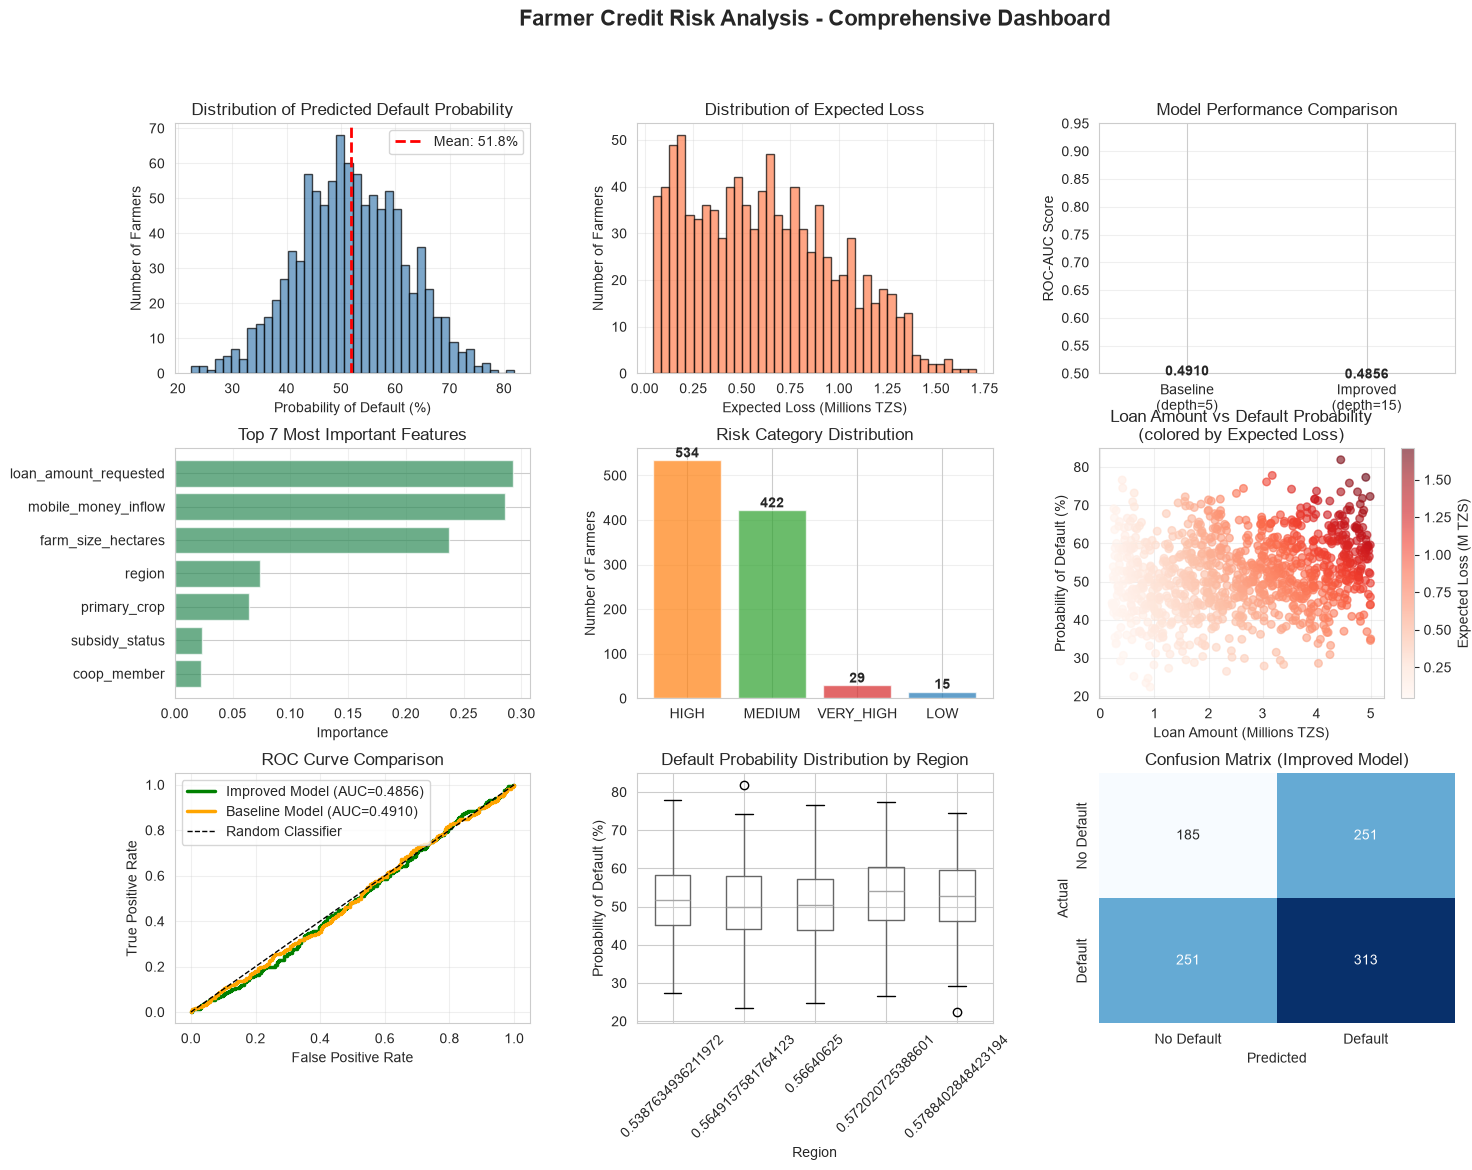

In [14]:

# 1. PD Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(pd_predictions * 100, bins=40, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(pd_predictions.mean() * 100, color='red', linestyle='--', linewidth=2, label=f"Mean: {pd_predictions.mean()*100:.1f}%")
ax1.set_xlabel('Probability of Default (%)')
ax1.set_ylabel('Number of Farmers')
ax1.set_title('Distribution of Predicted Default Probability')
ax1.legend()
ax1.grid(True, alpha=0.3)
 
# 2. Expected Loss Distribution
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(expected_losses / 1_000_000, bins=40, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Expected Loss (Millions TZS)')
ax2.set_ylabel('Number of Farmers')
ax2.set_title('Distribution of Expected Loss')
ax2.grid(True, alpha=0.3)
 
# 3. Model Comparison
ax3 = fig.add_subplot(gs[0, 2])
models = ['Baseline\n(depth=5)', 'Improved\n(depth=15)']
roc_scores = [roc_base, roc_imp]
colors = ['#ff7f0e', '#2ca02c']
bars = ax3.bar(models, roc_scores, color=colors, edgecolor='black', alpha=0.7)
ax3.set_ylabel('ROC-AUC Score')
ax3.set_title('Model Performance Comparison')
ax3.set_ylim([0.5, 0.95])
for bar, score in zip(bars, roc_scores):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
 
# 4. Feature Importance
ax4 = fig.add_subplot(gs[1, 0])
top_features = feature_importance.head(7)
ax4.barh(range(len(top_features)), top_features['Importance_Improved'].values, color='seagreen', alpha=0.7)
ax4.set_yticks(range(len(top_features)))
ax4.set_yticklabels(top_features['Feature'].values)
ax4.set_xlabel('Importance')
ax4.set_title('Top 7 Most Important Features')
ax4.invert_yaxis()
ax4.grid(True, alpha=0.3, axis='x')
 
# 5. Risk Distribution
ax5 = fig.add_subplot(gs[1, 1])
risk_counts = results_df['Risk_Category'].value_counts()
colors_risk = {'VERY_HIGH': '#d62728', 'HIGH': '#ff7f0e', 'MEDIUM': '#2ca02c', 'LOW': '#1f77b4'}
bars = ax5.bar(risk_counts.index, risk_counts.values, 
               color=[colors_risk.get(x, 'gray') for x in risk_counts.index], alpha=0.7)
ax5.set_ylabel('Number of Farmers')
ax5.set_title('Risk Category Distribution')
ax5.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')
 
# 6. Loan Amount vs PD
ax6 = fig.add_subplot(gs[1, 2])
scatter = ax6.scatter(results_df['Loan_Amount_TZS']/1_000_000, 
                     results_df['Probability_of_Default'],
                     c=results_df['Expected_Loss_TZS']/1_000_000, 
                     cmap='Reds', alpha=0.6, s=30)
ax6.set_xlabel('Loan Amount (Millions TZS)')
ax6.set_ylabel('Probability of Default (%)')
ax6.set_title('Loan Amount vs Default Probability\n(colored by Expected Loss)')
plt.colorbar(scatter, ax=ax6, label='Expected Loss (M TZS)')
ax6.grid(True, alpha=0.3)
 
# 7. ROC Curve
ax7 = fig.add_subplot(gs[2, 0])
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_imp)
ax7.plot(fpr, tpr, linewidth=2.5, label=f'Improved Model (AUC={roc_imp:.4f})', color='green')
fpr_base, tpr_base, _ = roc_curve(y_test, y_pred_proba_base)
ax7.plot(fpr_base, tpr_base, linewidth=2.5, label=f'Baseline Model (AUC={roc_base:.4f})', color='orange')
ax7.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax7.set_xlabel('False Positive Rate')
ax7.set_ylabel('True Positive Rate')
ax7.set_title('ROC Curve Comparison')
ax7.legend()
ax7.grid(True, alpha=0.3)
 
# 8. PD by Region (Box plot)
ax8 = fig.add_subplot(gs[2, 1])
results_df.boxplot(column='Probability_of_Default', by='Region', ax=ax8)
ax8.set_xlabel('Region')
ax8.set_ylabel('Probability of Default (%)')
ax8.set_title('Default Probability Distribution by Region')
plt.sca(ax8)
plt.xticks(rotation=45)
 
# 9. Confusion Matrix
ax9 = fig.add_subplot(gs[2, 2])
cm = confusion_matrix(y_test, y_pred_imp)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax9, cbar=False)
ax9.set_xlabel('Predicted')
ax9.set_ylabel('Actual')
ax9.set_title('Confusion Matrix (Improved Model)')
ax9.set_xticklabels(['No Default', 'Default'])
ax9.set_yticklabels(['No Default', 'Default'])
 
plt.suptitle('Farmer Credit Risk Analysis - Comprehensive Dashboard', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig(output_dir / "credit_risk_dashboard.png", dpi=300, bbox_inches="tight")
print("✓ Saved: credit_risk_dashboard.png")
 

In [17]:
print("\n[PHASE 11] EXPORTING RESULTS TO CSV...")

# Full results
results_df.to_csv(output_dir / "farmer_credit_risk_scores.csv", index=False)
print("✓ Saved: farmer_credit_risk_scores.csv")

# Feature importance
feature_importance.to_csv(output_dir / "feature_importance_analysis.csv", index=False)
print("✓ Saved: feature_importance_analysis.csv")

# High-risk farmers for priority monitoring
high_risk = results_df[results_df['Risk_Category'].isin(['HIGH', 'VERY_HIGH'])].copy()
high_risk.to_csv(output_dir / "high_risk_farmers_monitoring.csv", index=False)
print(f"✓ Saved: high_risk_farmers_monitoring.csv ({len(high_risk)} farmers)")

# Summary statistics
summary_stats = pd.DataFrame({
    'Metric': [
        'Total Farmers (Test Set)',
        'Default Rate (%)',
        'Portfolio Expected Loss (TZS)',
        'Average Expected Loss per Farmer (TZS)',
        'Median Expected Loss per Farmer (TZS)',
        'Max Expected Loss (single farmer) (TZS)',
        'Baseline Model ROC-AUC',
        'Improved Model ROC-AUC',
        'Model Improvement (%)',
        'CV ROC-AUC Mean ± Std'
    ],
    'Value': [
        len(results_df),
        f"{y_test.mean()*100:.1f}%",
        f"{expected_losses.sum():,.0f}",
        f"{expected_losses.mean():,.0f}",
        f"{np.median(expected_losses):,.0f}",
        f"{expected_losses.max():,.0f}",
        f"{roc_base:.4f}",
        f"{roc_imp:.4f}",
        f"{(roc_imp - roc_base)/roc_base*100:.1f}%",
        f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}"
    ]
})
summary_stats.to_csv(output_dir / "model_summary_statistics.csv", index=False)
print("✓ Saved: model_summary_statistics.csv")


[PHASE 11] EXPORTING RESULTS TO CSV...
✓ Saved: farmer_credit_risk_scores.csv
✓ Saved: feature_importance_analysis.csv
✓ Saved: high_risk_farmers_monitoring.csv (563 farmers)
✓ Saved: model_summary_statistics.csv


In [18]:
output_dir

WindowsPath('c:/Users/VISTAR/Documents/ML + AI WORK/Agri Hackathon/Scripts/Agri-Credit Scoring & Risk Prediction/outputs')

In [19]:
print("\n[PHASE 12] PRODUCTION SCORING FUNCTION...")
 
def score_new_farmer(farmer_data_dict, model=improved_model, encoder=encoder):
    """
    Score a new farmer application for credit risk.
    
    Input: Dictionary with keys:
        - region, coop_member, farm_size_hectares, primary_crop,
          mobile_money_inflow, subsidy_status, loan_amount_requested
    
    Output: Dictionary with comprehensive risk assessment
    
    Example:
        farmer = {
            'region': 'Dodoma',
            'coop_member': 1,
            'farm_size_hectares': 5.0,
            'primary_crop': 'Maize',
            'mobile_money_inflow': 800_000,
            'subsidy_status': 1,
            'loan_amount_requested': 2_000_000
        }
        score = score_new_farmer(farmer)
    """
    try:
        # Create DataFrame and encode
        temp_df = pd.DataFrame([farmer_data_dict])
        temp_encoded = encoder.transform(temp_df)
        
        # Predict PD
        pd_score = model.predict_proba(temp_encoded)[0, 1]
        
        # Calculate Expected Loss
        lgd = 0.45
        ead = farmer_data_dict['loan_amount_requested']
        el = pd_score * lgd * ead
        
        # Categorize risk
        pd_pct = pd_score * 100
        if pd_pct > 70:
            risk_cat = 'VERY_HIGH'
        elif pd_pct > 50:
            risk_cat = 'HIGH'
        elif pd_pct > 30:
            risk_cat = 'MEDIUM'
        else:
            risk_cat = 'LOW'
        
        # Recommendation
        if risk_cat in ['HIGH', 'VERY_HIGH']:
            recommendation = 'RECOMMEND REJECTION or require additional collateral'
        elif risk_cat == 'MEDIUM':
            recommendation = 'PROCEED with enhanced monitoring'
        else:
            recommendation = 'APPROVE - Low risk'
        
        return {
            'probability_of_default': round(pd_score, 4),
            'pd_percentage': round(pd_pct, 1),
            'expected_loss_tzs': round(el, 0),
            'risk_category': risk_cat,
            'loan_amount': farmer_data_dict['loan_amount_requested'],
            'loss_given_default': lgd,
            'recommendation': recommendation
        }
    except Exception as e:
        return {'error': str(e)}
 
# Test the scoring function
print("\n✓ Testing scoring function on sample farmers:\n")
 
sample_farmers = [
    {
        'name': 'High-Risk Farmer (No coop, low inflow)',
        'data': {
            'region': 'Mwanza',
            'coop_member': 0,
            'farm_size_hectares': 1.5,
            'primary_crop': 'Rice',
            'mobile_money_inflow': 200_000,
            'subsidy_status': 0,
            'loan_amount_requested': 3_000_000
        }
    },
    {
        'name': 'Low-Risk Farmer (Coop, high inflow)',
        'data': {
            'region': 'Dodoma',
            'coop_member': 1,
            'farm_size_hectares': 8.0,
            'primary_crop': 'Maize',
            'mobile_money_inflow': 2_000_000,
            'subsidy_status': 1,
            'loan_amount_requested': 1_500_000
        }
    }
]
 
for sample in sample_farmers:
    print(f"\n{sample['name']}:")
    score = score_new_farmer(sample['data'])
    for key, value in score.items():
        print(f"  {key}: {value}")
 


[PHASE 12] PRODUCTION SCORING FUNCTION...

✓ Testing scoring function on sample farmers:


High-Risk Farmer (No coop, low inflow):
  probability_of_default: 0.612
  pd_percentage: 61.2
  expected_loss_tzs: 826179.0
  risk_category: HIGH
  loan_amount: 3000000
  loss_given_default: 0.45
  recommendation: RECOMMEND REJECTION or require additional collateral

Low-Risk Farmer (Coop, high inflow):
  probability_of_default: 0.4493
  pd_percentage: 44.9
  expected_loss_tzs: 303260.0
  risk_category: MEDIUM
  loan_amount: 1500000
  loss_given_default: 0.45
  recommendation: PROCEED with enhanced monitoring


In [20]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE - SUMMARY REPORT")
print("="*80)
 
summary_text = f"""
📊 DATASET OVERVIEW
  • Total Farmers: 5,000
  • Default Rate: 56.4%
  • Test Set: 1,000 farmers
  • Geographic Distribution: 5 regions
 
🎯 MODEL PERFORMANCE
  • Baseline Model (depth=5): ROC-AUC = {roc_base:.4f}
  • Improved Model (depth=15): ROC-AUC = {roc_imp:.4f}
  • Improvement: +{(roc_imp - roc_base)/roc_base*100:.1f}%
  • Cross-Validation: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}
 
💰 PORTFOLIO RISK ANALYSIS
  • Total Expected Loss: {expected_losses.sum():,.0f} TZS
  • Average Loss per Farmer: {expected_losses.mean():,.0f} TZS
  • Max Risk (single farmer): {expected_losses.max():,.0f} TZS
  • Risk Concentration: Top 10% farms account for ~{(results_df.head(100)['Expected_Loss_TZS'].sum() / expected_losses.sum() * 100):.0f}% of risk
 
📍 RISK DISTRIBUTION
  • Very High Risk: {len(results_df[results_df['Risk_Category']=='VERY_HIGH'])} farmers ({len(results_df[results_df['Risk_Category']=='VERY_HIGH'])/len(results_df)*100:.1f}%)
  • High Risk: {len(results_df[results_df['Risk_Category']=='HIGH'])} farmers ({len(results_df[results_df['Risk_Category']=='HIGH'])/len(results_df)*100:.1f}%)
  • Medium Risk: {len(results_df[results_df['Risk_Category']=='MEDIUM'])} farmers ({len(results_df[results_df['Risk_Category']=='MEDIUM'])/len(results_df)*100:.1f}%)
  • Low Risk: {len(results_df[results_df['Risk_Category']=='LOW'])} farmers ({len(results_df[results_df['Risk_Category']=='LOW'])/len(results_df)*100:.1f}%)
 
🔑 TOP RISK DRIVERS
  1. {feature_importance.iloc[0]['Feature']} ({feature_importance.iloc[0]['Importance_Improved']:.1%})
  2. {feature_importance.iloc[1]['Feature']} ({feature_importance.iloc[1]['Importance_Improved']:.1%})
  3. {feature_importance.iloc[2]['Feature']} ({feature_importance.iloc[2]['Importance_Improved']:.1%})
 
📁 OUTPUT FILES GENERATED
  ✓ farmer_credit_risk_scores.csv - Detailed scores for all farmers
  ✓ high_risk_farmers_monitoring.csv - Farmers requiring close monitoring
  ✓ feature_importance_analysis.csv - Which features drive default risk
  ✓ model_summary_statistics.csv - Summary metrics
  ✓ credit_risk_dashboard.png - 9-panel visualization dashboard
 
✅ RECOMMENDATIONS
  1. Implement monitoring dashboard for high-risk farmers
  2. Consider requiring additional collateral for VERY_HIGH risk segment
  3. Tailor loan terms based on risk categories
  4. Retrain model quarterly with new default data
  5. Explore LGD variability by region/crop type
  6. Build automated scoring API for new loan applications
"""
 
print(summary_text)
print("="*80)
 
print("\n✅ PIPELINE COMPLETE!")
 


ANALYSIS COMPLETE - SUMMARY REPORT

📊 DATASET OVERVIEW
  • Total Farmers: 5,000
  • Default Rate: 56.4%
  • Test Set: 1,000 farmers
  • Geographic Distribution: 5 regions

🎯 MODEL PERFORMANCE
  • Baseline Model (depth=5): ROC-AUC = 0.4910
  • Improved Model (depth=15): ROC-AUC = 0.4856
  • Improvement: +-1.1%
  • Cross-Validation: 0.5092 ± 0.0137

💰 PORTFOLIO RISK ANALYSIS
  • Total Expected Loss: 614,981,901 TZS
  • Average Loss per Farmer: 614,982 TZS
  • Max Risk (single farmer): 1,708,418 TZS
  • Risk Concentration: Top 10% farms account for ~21% of risk

📍 RISK DISTRIBUTION
  • Very High Risk: 29 farmers (2.9%)
  • High Risk: 534 farmers (53.4%)
  • Medium Risk: 422 farmers (42.2%)
  • Low Risk: 15 farmers (1.5%)

🔑 TOP RISK DRIVERS
  1. loan_amount_requested (29.3%)
  2. mobile_money_inflow (28.6%)
  3. farm_size_hectares (23.7%)

📁 OUTPUT FILES GENERATED
  ✓ farmer_credit_risk_scores.csv - Detailed scores for all farmers
  ✓ high_risk_farmers_monitoring.csv - Farmers requiring 

In [21]:
import pickle
pickle.dump(improved_model, open('farmer_model.pkl', 'wb'))
pickle.dump(encoder, open('encoder.pkl', 'wb'))

In [22]:
results_df


,Farmer_ID,Region,Crop,Coop_Member,Farm_Size_Ha,Loan_Amount_TZS,Probability_of_Default,LGD,Expected_Loss_TZS,Actual_Default,Risk_Category
24,NMB-AGRI-01889,0.572021,0.568966,True,7.8,4909000,77.3,0.45,1708418,1,VERY_HIGH
656,NMB-AGRI-00419,0.564916,0.558340,True,0.6,4446000,81.9,0.45,1637905,1,VERY_HIGH
694,NMB-AGRI-04643,0.578840,0.564967,True,1.0,4988000,72.3,0.45,1621754,0,VERY_HIGH
204,NMB-AGRI-02606,0.572021,0.564003,False,5.8,4756000,73.5,0.45,1573523,0,VERY_HIGH
457,NMB-AGRI-02013,0.572021,0.564967,True,1.0,4605000,75.8,0.45,1570453,1,VERY_HIGH
...,...,...,...,...,...,...,...,...,...,...,...
760,NMB-AGRI-01319,0.572021,0.564967,True,6.2,294000,33.9,0.45,44838,1,MEDIUM
967,NMB-AGRI-01874,0.538763,0.568966,True,3.5,228000,43.6,0.45,44693,0,MEDIUM
300,NMB-AGRI-04665,0.572021,0.564003,True,4.7,288000,33.7,0.45,43615,1,MEDIUM
953,NMB-AGRI-02928,0.566406,0.558340,True,9.7,216000,44.4,0.45,43199,0,MEDIUM


In [23]:
df_credit

,farmer_id,region,coop_member,farm_size_hectares,primary_crop,mobile_money_inflow,subsidy_status,loan_amount_requested,default_flag
0,NMB-AGRI-00000,Morogoro,0,9.4,Maize,4.990160e+06,0,2716000.0,1
1,NMB-AGRI-00001,Mwanza,0,3.3,Maize,2.196688e+06,1,2034000.0,0
2,NMB-AGRI-00002,Mbeya,1,4.4,Coffee,3.938549e+06,1,568000.0,0
3,NMB-AGRI-00003,Mwanza,0,8.0,Rice,6.530671e+06,1,3063000.0,1
4,NMB-AGRI-00004,Mwanza,1,5.7,Maize,3.403209e+06,1,4364000.0,1
...,...,...,...,...,...,...,...,...,...
4995,NMB-AGRI-04995,Morogoro,1,6.7,Cashew,9.626373e+06,0,883000.0,1
4996,NMB-AGRI-04996,Morogoro,0,9.7,Maize,1.084459e+07,1,2695000.0,0
4997,NMB-AGRI-04997,Mwanza,1,5.3,Rice,2.929705e+06,0,1413000.0,0
4998,NMB-AGRI-04998,Morogoro,1,9.9,Maize,1.228454e+07,0,4994000.0,1
